# **Emotion Analysis**

Refrence Research
https://kuey.net/index.php/kuey/article/view/2986/1895

## **import liberaries**

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##**Loading The Data**

In [ ]:
#Dataset is imported from kaggle
data = pd.read_csv('Emotion_final.csv')

data.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Data Exploration and Visualization

In [ ]:
data.shape

(21459, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB




---


No Null values

In [ ]:
data.duplicated().sum()

3

In [ ]:
data.drop_duplicates()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
21454,Melissa stared at her friend in dism,fear
21455,Successive state elections have seen the gover...,fear
21456,Vincent was irritated but not dismay,fear
21457,Kendall-Hume turned back to face the dismayed ...,fear


<Axes: xlabel='Emotion', ylabel='count'>

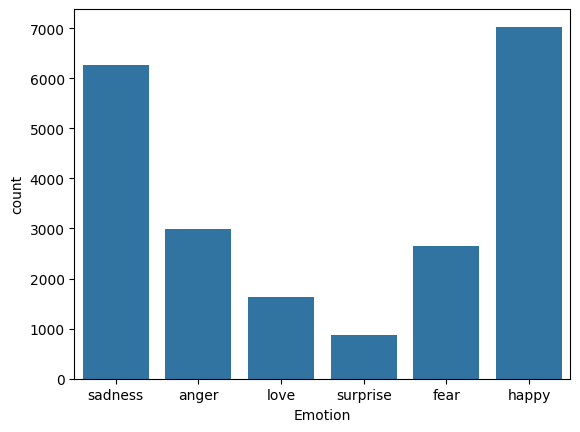

In [ ]:
#Distribution of data
sns.countplot(x = data['Emotion'])



---
 **Data is imbalanced**


##**Data Preprocessing**

In [ ]:
label_to_emotion = {"anger":0,"fear":1,"happy":2,"love":3, "sadness":4, "surprise":5}
data['Emotion'] = data['Emotion'].map(label_to_emotion)
data.head()

,Text,Emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


In [ ]:
#clean and preprocess the data
lemmatizer = WordNetLemmatizer()

stopwords = set(nltk.corpus.stopwords.words('english'))
#Function for data Cleaning
def clean_text(text):
    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stopwords]
    return " ".join(text)

clean_text(data['Text'][0])

'didnt feel humiliated'

In [ ]:
#spliting the data into train and test
X_train, X_test, y_train, y_test = train_test_split( data['Text'], data['Emotion'], test_size=0.2, random_state=42)

In [ ]:
#preprocess train and test
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

In [ ]:
#turn text into vectors
tfidf_vectorizer = TfidfVectorizer()
X_train_vector = tfidf_vectorizer.fit_transform(X_train)
X_test_vector = tfidf_vectorizer.transform(X_test)

In [ ]:
#balancing the data for better accuracy
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_vector, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



Class distribution after SMOTE:
Emotion
2    5648
3    5648
1    5648
4    5648
5    5648
0    5648
Name: count, dtype: int64


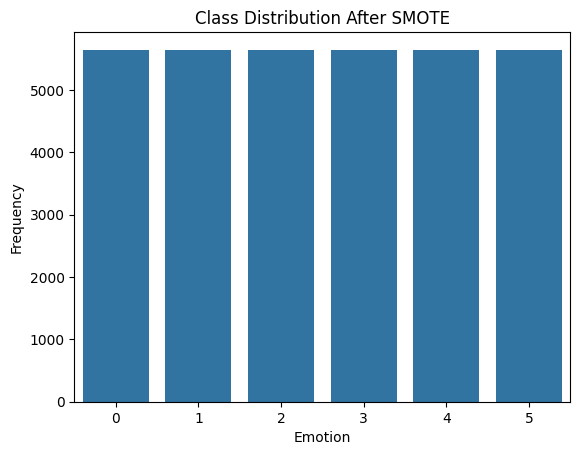

In [ ]:
# Class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

plt.figure()
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.show()

## **Modelling**

### **Train SVM model with balanced data**


SVM Results:
Accuracy: 0.89
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88       617
           1       0.86      0.85      0.85       531
           2       0.93      0.89      0.91      1381
           3       0.74      0.88      0.80       318
           4       0.94      0.91      0.92      1277
           5       0.67      0.79      0.73       168

    accuracy                           0.89      4292
   macro avg       0.84      0.87      0.85      4292
weighted avg       0.89      0.89      0.89      4292



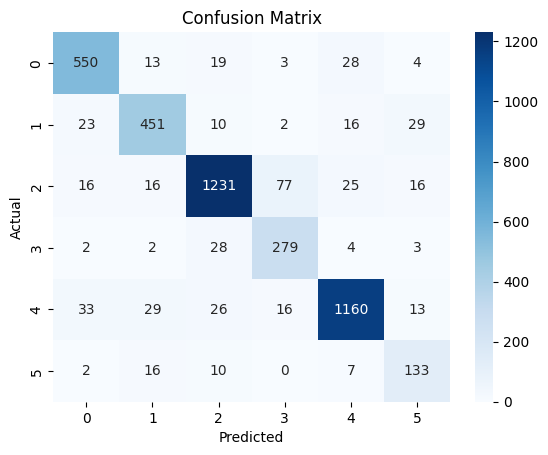

In [ ]:
# Initialize the SVM model
svm_model = SVC(kernel='linear',random_state=42)

# Train the model using the resampled data
svm_model.fit(X_resampled, y_resampled)
# Predict on the test data
y_pred = svm_model.predict(X_test_vector)
svm_accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Results:")
print(f"Accuracy: {svm_accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### **Random Forest Model**


Random Forest Model Results:
Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       617
           1       0.83      0.86      0.84       531
           2       0.88      0.88      0.88      1381
           3       0.72      0.82      0.77       318
           4       0.93      0.86      0.89      1277
           5       0.73      0.82      0.77       168

    accuracy                           0.87      4292
   macro avg       0.83      0.85      0.84      4292
weighted avg       0.87      0.87      0.87      4292



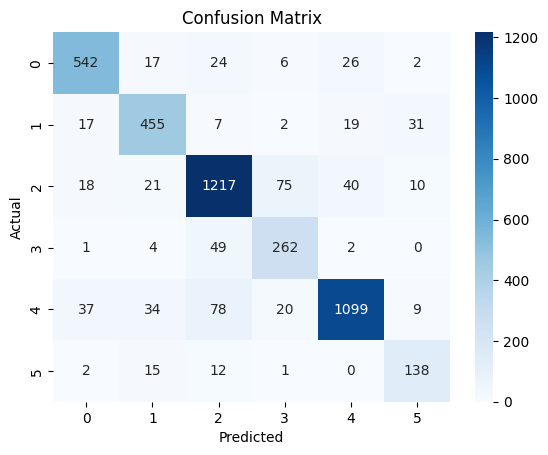

In [ ]:
#random forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_resampled, y_resampled)
rf_pred = rf_model.predict(X_test_vector)


rf_accuracy = accuracy_score(y_test, rf_pred)

rf_classification_rep = classification_report(y_test, rf_pred)

print("\nRandom Forest Model Results:")
print(f"Accuracy: {rf_accuracy:.2f}")
print(f"Classification Report:\n{rf_classification_rep}")
# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.figure(figsize=(8, 6))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Decision Tree Model Results:
Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       617
           1       0.82      0.84      0.83       531
           2       0.89      0.86      0.87      1381
           3       0.73      0.82      0.77       318
           4       0.88      0.87      0.87      1277
           5       0.68      0.81      0.74       168

    accuracy                           0.85      4292
   macro avg       0.81      0.84      0.83      4292
weighted avg       0.86      0.85      0.85      4292



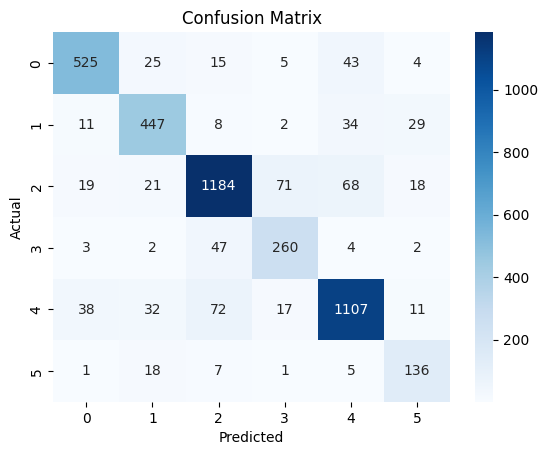

In [ ]:
#Decision Tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_resampled, y_resampled)
dt_pred = dt_model.predict(X_test_vector)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_classification_rep = classification_report(y_test, dt_pred)

print("\nDecision Tree Model Results:")
print(f"Accuracy: {dt_accuracy:.2f}")
print(f"Classification Report:\n{dt_classification_rep}")

# Confusion matrix
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Result**

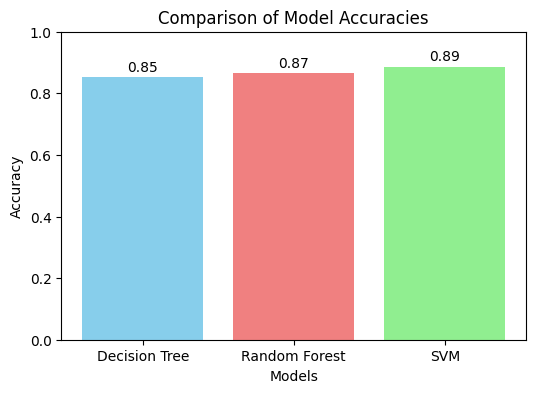

In [ ]:
accuracies = {
    'Decision Tree': dt_accuracy,
    'Random Forest': rf_accuracy,
    'SVM': svm_accuracy
}

models = list(accuracies.keys())
accuracy_values = list(accuracies.values())

plt.figure(figsize=(6, 4))
plt.bar(models, accuracy_values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.ylim(0, 1)
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')
plt.show()

# **Deployment**

In [ ]:
# Reverse the mapping for decoding
emotion_to_label = {v: k for k, v in label_to_emotion.items()}

def predict_emotion(input_text, model, model_name):
    cleaned_text = clean_text(input_text)
    input_vectorized = vectorizer.transform([cleaned_text])

    predicted_emotion_label = model.predict(input_vectorized)[0]
    predicted_emotion = emotion_to_label[predicted_emotion_label]

    print(f"\n{model_name} Prediction:")
    print(f"Input Text: {input_text}")
    print(f"Predicted Emotion: {predicted_emotion}")
    print("-" * 50)

# Example usage
new_text_1 = "I am feeling so happy and excited today!"
predict_emotion(new_text_1, svm_model, "SVM")


SVM Prediction:
Input Text: I am feeling so happy and excited today!
Predicted Emotion: happy
--------------------------------------------------
